<a href="https://colab.research.google.com/github/Shreyas-coding-master001/Machine_Learning_Seires/blob/main/Basic_Prepocessing/Feature_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv("/content/student-por.csv", sep=";")

In [38]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

### DataFrame Column Explanations

Below is a detailed explanation of each column in the `df` DataFrame:

- **school** (Data Type: `object`): Student’s school (binary: GP - Gabriel Pereira or MS - Mousinho da Silveira)  ✅
- **sex** (Data Type: `object`): Student’s sex (binary: F - female or M - male)  : ✅
- **age** (Data Type: `int64`): Student’s age (numeric: from 15 to 22)  ⛔
- **address** (Data Type: `object`): Student’s home address type (binary: U - urban or R - rural)
- **famsize** (Data Type: `object`): Family size (binary: LE3 - less or equal to 3 or GT3 - greater than 3)
- **Pstatus** (Data Type: `object`): Parent’s cohabitation status (binary: T - living together or A - apart)
- **Medu** (Data Type: `int64`): Mother’s education (numeric: 0 - none, 1 - primary education (4th grade), 2 - 5th to 9th grade, 3 - secondary education or 4 - higher education)
- **Fedu** (Data Type: `int64`): Father’s education (numeric: 0 - none, 1 - primary education (4th grade), 2 - 5th to 9th grade, 3 - secondary education or 4 - higher education)
- **Mjob** (Data Type: `object`): Mother’s job (nominal: at_home, health, other, services, teacher)
- **Fjob** (Data Type: `object`): Father’s job (nominal: at_home, health, other, services, teacher)
- **reason** (Data Type: `object`): Reason to choose this school (nominal: home, reputation, course, other)
- **guardian** (Data Type: `object`): Student’s guardian (nominal: mother, father, other)
- **traveltime** (Data Type: `int64`): Home to school travel time (numeric: 1 - <15 min., 2 - 15 to 30 min., 3 - 30 min. to 1 hour, or 4 - >1 hour)
- **studytime** (Data Type: `int64`): Weekly study time (numeric: 1 - <2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - >10 hours)
- **failures** (Data Type: `int64`): Number of past class failures (numeric: n if 1<=n<3, else 4)
- **schoolsup** (Data Type: `object`): Extra educational support (binary: yes or no)
- **famsup** (Data Type: `object`): Family educational support (binary: yes or no)
- **paid** (Data Type: `object`): Extra paid classes within the course subject (Math or Portuguese) (binary: yes or no)
- **activities** (Data Type: `object`): Extra-curricular activities (binary: yes or no)
- **nursery** (Data Type: `object`): Attended nursery school (binary: yes or no)
- **higher** (Data Type: `object`): Wants to take higher education (binary: yes or no)
- **internet** (Data Type: `object`): Internet access at home (binary: yes or no)
- **romantic** (Data Type: `object`): With a romantic relationship (binary: yes or no)
- **famrel** (Data Type: `int64`): Quality of family relationships (numeric: from 1 - very bad to 5 - excellent)
- **freetime** (Data Type: `int64`): Free time after school (numeric: from 1 - very low to 5 - very high)
- **goout** (Data Type: `int64`): Going out with friends (numeric: from 1 - very low to 5 - very high)
- **Dalc** (Data Type: `int64`): Workday alcohol consumption (numeric: from 1 - very low to 5 - very high)
- **Walc** (Data Type: `int64`): Weekend alcohol consumption (numeric: from 1 - very low to 5 - very high)
- **health** (Data Type: `int64`): Current health status (numeric: from 1 - very bad to 5 - very good)
- **absences** (Data Type: `int64`): Number of school absences (numeric: from 0 to 93)
- **G1** (Data Type: `int64`): First period grade (numeric: from 0 to 20)
- **G2** (Data Type: `int64`): Second period grade (numeric: from 0 to 20)
- **G3** (Data Type: `int64`): Final grade (numeric: from 0 to 20)

In [40]:
from scipy.stats import f_oneway

gp_g3 = df[df["school"] == "GP"]['G3']
ms_g3 = df[df["school"] == "MS"]['G3']

f_static,  p_value = f_oneway(gp_g3, ms_g3)

if p_value > 0.05 :
  print("We accept the null hypothesis(no significant differnces)")
else:
  print("We reject the null hypothesis(significant differnces)")

We reject the null hypothesis(significant differnces)


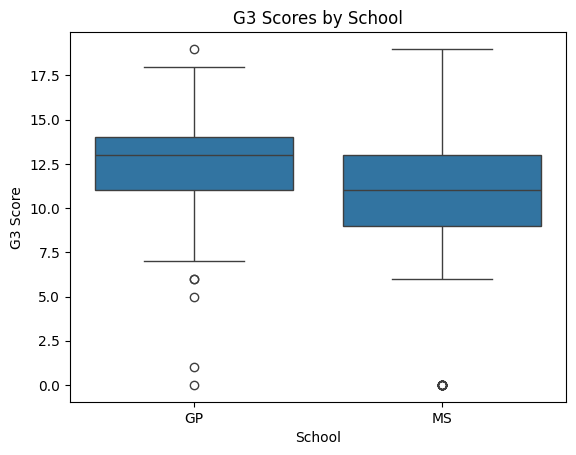

In [41]:
sns.boxplot(x="school" ,y="G3" ,data=df)
plt.title("G3 Scores by School")
plt.xlabel("School")
plt.ylabel("G3 Score")
plt.show()

In [42]:
male_g3 = df[df["sex"] == "M"]['G3']
female_g3 = df[df["sex"] == "F"]['G3']

f_static,  p_value = f_oneway(male_g3, female_g3)

if p_value > 0.05 :
  print("We accept the null hypothesis(no significant differnces)")
else:
  print("We reject the null hypothesis(significant differnces)")

We reject the null hypothesis(significant differnces)


In [43]:
import pandas as pd
from scipy.stats import f_oneway

def analyze_categorical_g3_relationship(df, target_column='G3', max_unique_values=5):
    """
    Analyzes the relationship between potentially categorical columns (those with
    <= max_unique_values) and a numerical target column using one-way ANOVA.

    Args:
        df (pd.DataFrame): The input DataFrame.
        target_column (str): The name of the numerical target column (e.g., 'G3').
        max_unique_values (int): The maximum number of unique values for a column
                                 to be considered categorical for this analysis.

    Returns:
        pd.DataFrame: A DataFrame containing the F-statistic and p-value for
                      each relevant categorical column.
    """
    results = []

    # Iterate through all columns to find those that can be treated as categorical
    for col in df.columns:
        # Exclude the target column itself
        if col == target_column:
            continue

        print(f"--- Analyzing {col} ---")
        # Check if the column has a small number of unique values
        if df[col].nunique() <= max_unique_values:
            # Get unique categories
            categories = df[col].unique()

            # Prepare data for ANOVA for each category
            data_for_anova = []
            for cat in categories:
                # Ensure the data for ANOVA is numerical and not empty
                g3_scores = df[df[col] == cat][target_column].dropna()
                if not g3_scores.empty:
                    data_for_anova.append(g3_scores)

            # Perform ANOVA only if there are at least two groups with data
            if len(data_for_anova) >= 2 and all(len(group) > 1 for group in data_for_anova):
                try:
                    f_statistic, p_value = f_oneway(*data_for_anova)
                    results.append({'Column': col, 'F-statistic': f_statistic, 'P-value': p_value})
                    print(f"value : {p_value:.6f}")

                    if p_value > 0.05:
                      print("result : Accepted null hypothesis - no significant difference")
                    else:
                      print("result : Rejected null hypothesis - significant difference Found")
                except ValueError:
                    results.append({'Column': col, 'F-statistic': 'N/A', 'P-value': 'N/A', 'Note': 'ANOVA calculation failed'})
            else:
                results.append({'Column': col, 'F-statistic': 'N/A', 'P-value': 'N/A', 'Note': 'Not enough distinct groups or samples per group for ANOVA'})
        else:
          print("Numerical Data")
    return pd.DataFrame(results)

# Apply the function to the DataFrame
print("Analysis of Categorical/Quasi-Categorical Features vs. G3 Score (using ANOVA):")
categorical_analysis_results = analyze_categorical_g3_relationship(df, target_column='G3', max_unique_values=5)


Analysis of Categorical/Quasi-Categorical Features vs. G3 Score (using ANOVA):
--- Analyzing school ---
value : 0.000000
result : Rejected null hypothesis - significant difference Found
--- Analyzing sex ---
value : 0.000982
result : Rejected null hypothesis - significant difference Found
--- Analyzing age ---
Numerical Data
--- Analyzing address ---
value : 0.000018
result : Rejected null hypothesis - significant difference Found
--- Analyzing famsize ---
value : 0.252133
result : Accepted null hypothesis - no significant difference
--- Analyzing Pstatus ---
value : 0.984706
result : Accepted null hypothesis - no significant difference
--- Analyzing Medu ---
value : 0.000000
result : Rejected null hypothesis - significant difference Found
--- Analyzing Fedu ---
value : 0.000002
result : Rejected null hypothesis - significant difference Found
--- Analyzing Mjob ---
value : 0.000008
result : Rejected null hypothesis - significant difference Found
--- Analyzing Fjob ---
value : 0.011376


### ANOVA Results Summary (Categorical Features vs. G3 Score)

| Column | F-statistic | P-value | Hypothesis Result |
|:-------|:------------|:--------|:------------------|
| school | 56.89 | 0.000000 | ✅ (Rejected Null) |
| sex | 10.96 | 0.000982 | ✅ (Rejected Null) |
| age | --- | -0.1065 | ⛔ (Weak Correlation) |
| address | 18.71 | 0.000018 | ✅ (Rejected Null) |
| famsize | 1.31 | 0.252133 | ⛔ (Accepted Null) |
| Pstatus | 0.00 | 0.984706 | ⛔ (Accepted Null) |
| Medu | 10.76 | 0.000000 | ✅ (Rejected Null) |
| Fedu | 8.22 | 0.000002 | ✅ (Rejected Null) |
| Mjob | 7.37 | 0.000008 | ✅ (Rejected Null) |
| Fjob | 3.27 | 0.011376 | ✅ (Rejected Null) |
| reason | 10.25 | 0.000001 | ✅ (Rejected Null) |
| guardian | 2.64 | 0.072262 | ⛔ (Accepted Null) |
| traveltime | 3.66 | 0.012321 | ✅ (Rejected Null) |
| studytime | 15.88 | 0.000000 | ✅ (Rejected Null) |
| failures | 51.39 | 0.000000 | ✅ (Rejected Null) |
| schoolsup | 2.87 | 0.090971 | ⛔ (Accepted Null) |
| famsup | 2.28 | 0.131887 | ⛔ (Accepted Null) |
| paid | 1.96 | 0.162441 | ⛔ (Accepted Null) |
| activities | 2.32 | 0.128099 | ⛔ (Accepted Null) |
| nursery | 0.54 | 0.464645 | ⛔ (Accepted Null) |
| higher | 80.24 | 0.000000 | ✅ (Rejected Null) |
| internet | 14.90 | 0.000125 | ✅ (Rejected Null) |
| romantic | 5.35 | 0.021002 | ✅ (Rejected Null) |
| famrel | 3.68 | 0.005685 | ✅ (Rejected Null) |
| freetime | 4.49 | 0.001390 | ✅ (Rejected Null) |
| goout | 6.99 | 0.000017 | ✅ (Rejected Null) |
| Dalc | 8.19 | 0.000002 | ✅ (Rejected Null) |
| Walc | 5.54 | 0.000219 | ✅ (Rejected Null) |
| health | 2.44 | 0.045741 | ✅ (Rejected Null) |
| absences | --- | -0.0913 | ⛔ (Weak Correlation) |
| G1 | --- | 0.8263 | ✅ (Strong Correlation) |
| G2 | --- | 0.9185 | ✅ (Strong Correlation) |

In [44]:
cor = df["age"].corr(df["G3"])

if abs(cor) > 0.5:
  print("Strong Correlation")
elif abs(cor) > 0.3:
  print("Moderate Correlation")
else:
  print("Weak Correlation")

Weak Correlation


In [45]:
def numeric_corr(dataframe, max_unique_values):
  for col in dataframe.columns:
    if col == "G3":
      continue

    if df[col].nunique() > max_unique_values:
      print(f"---  Correlation for {col} ---")
      cor = df[col].corr(df["G3"])

      print(f"value: {cor}")
      if abs(cor) > 0.5:
        print(f"Strong Correlation for {col}")
      elif abs(cor) > 0.3:
        print(f"Moderate Correlation for {col}")
      else:
        print(f"Weak Correlation for {col}")

      print()


numeric_corr(df, 5)

---  Correlation for age ---
value: -0.10650539063847857
Weak Correlation for age

---  Correlation for absences ---
value: -0.0913790564387561
Weak Correlation for absences

---  Correlation for G1 ---
value: 0.8263871247890474
Strong Correlation for G1

---  Correlation for G2 ---
value: 0.9185480035603504
Strong Correlation for G2



In [46]:
columns_to_drop = [
    'famsize', 'Pstatus', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
    'age', 'absences'
]

# Drop the identified columns from the DataFrame
df_cleaned = df.drop(columns=columns_to_drop)

print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape: {df_cleaned.shape}")

display(df_cleaned.head())

Original DataFrame shape: (649, 33)
Cleaned DataFrame shape: (649, 23)


,school,sex,address,Medu,Fedu,Mjob,Fjob,reason,traveltime,studytime,...,romantic,famrel,freetime,goout,Dalc,Walc,health,G1,G2,G3
0,GP,F,U,4,4,at_home,teacher,course,2,2,...,no,4,3,4,1,1,3,0,11,11
1,GP,F,U,1,1,at_home,other,course,1,2,...,no,5,3,3,1,1,3,9,11,11
2,GP,F,U,1,1,at_home,other,other,1,2,...,no,4,3,2,2,3,3,12,13,12
3,GP,F,U,4,2,health,services,home,1,3,...,yes,3,2,2,1,1,5,14,14,14
4,GP,F,U,3,3,other,other,home,1,2,...,no,4,3,2,1,2,5,11,13,13
